# 05 — Visualizations for Assignment 4

This notebook creates the three required visualizations:

1. Raw data visualization
2. Transformed data visualization
3. Model performance visualization

Figures are saved in `reports/figures/`.


## 1. Imports and paths


In [1]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Project root:", PROJECT_ROOT.resolve())
print("Figures directory:", FIGURES_DIR.resolve())


Project root: C:\Users\hugol\Desktop\Python\B2\ml-poc-project
Figures directory: C:\Users\hugol\Desktop\Python\B2\ml-poc-project\reports\figures


## 2. Load datasets


In [2]:
def latest_file(directory, pattern):
    files = sorted(directory.glob(pattern))
    return files[-1] if files else None

raw_path = latest_file(RAW_DATA_DIR, "idealista_raw_listings_*.csv")
clean_path = latest_file(PROCESSED_DATA_DIR, "idealista_clean_full_*.csv")
model_ready_path = PROCESSED_DATA_DIR / "idealista_model_ready_latest.csv"
metrics_path = REPORTS_DIR / "model_metrics_latest.csv"
predictions_path = PROCESSED_DATA_DIR / "model_predictions_latest.csv"

if raw_path is None:
    raise FileNotFoundError("No raw Idealista dataset found in data/raw/.")

raw_df = pd.read_csv(raw_path)
print("Raw dataset:", raw_path, raw_df.shape)

clean_df = pd.read_csv(clean_path) if clean_path is not None else None
print("Clean dataset:", clean_path, clean_df.shape if clean_df is not None else None)

model_df = pd.read_csv(model_ready_path) if model_ready_path.exists() else None
print("Model-ready dataset:", model_ready_path, model_df.shape if model_df is not None else None)

metrics_df = pd.read_csv(metrics_path) if metrics_path.exists() else None
print("Metrics dataset:", metrics_path, metrics_df.shape if metrics_df is not None else None)

predictions_df = pd.read_csv(predictions_path) if predictions_path.exists() else None
print("Predictions dataset:", predictions_path, predictions_df.shape if predictions_df is not None else None)


Raw dataset: ..\data\raw\idealista_raw_listings_20260430_185730.csv (500, 51)
Clean dataset: ..\data\processed\idealista_clean_full_20260505_095832.csv (489, 79)
Model-ready dataset: ..\data\processed\idealista_model_ready_latest.csv (489, 35)
Metrics dataset: ..\reports\model_metrics_latest.csv (3, 10)
Predictions dataset: ..\data\processed\model_predictions_latest.csv (98, 40)


## 3. Visualization 1 — Raw data: price distribution

Objective: understand raw listing price distribution and identify skewness/outliers.  
Chart type: histogram.


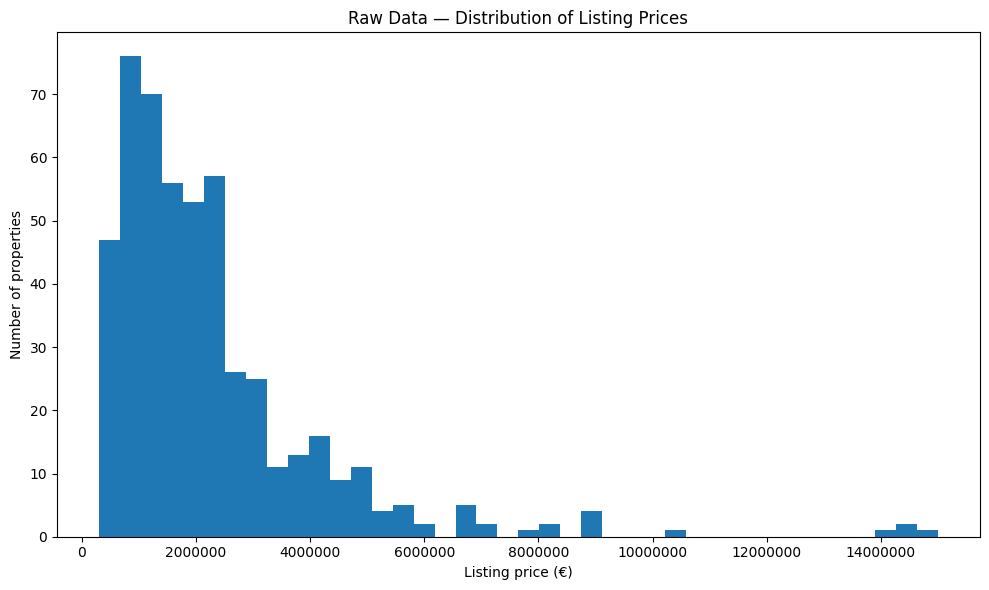

Saved: ..\reports\figures\d4_raw_price_distribution_20260507_175402.png


In [3]:
raw_plot_df = raw_df.copy()
raw_plot_df["price"] = pd.to_numeric(raw_plot_df["price"], errors="coerce")

plt.figure(figsize=(10, 6))
plt.hist(raw_plot_df["price"].dropna(), bins=40)
plt.title("Raw Data — Distribution of Listing Prices")
plt.xlabel("Listing price (€)")
plt.ylabel("Number of properties")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()

raw_price_fig_path = FIGURES_DIR / f"d4_raw_price_distribution_{timestamp}.png"
plt.savefig(raw_price_fig_path, dpi=150)
plt.show()
print("Saved:", raw_price_fig_path)


## 4. Visualization 2 — Transformed data: median price per m² by district

Objective: show how engineered features reveal location-based market differences.  
Chart type: bar chart.


,listings,median_price_per_m2
district,,
Barrio de Salamanca,132,"12,878.07"
Chamberí,57,"10,051.55"
Retiro,32,"9,797.54"
Chamartín,41,"9,405.59"
La Moraleja urbanización,15,"8,200.00"
Centro,63,"8,074.07"
Arganzuela,9,"7,671.23"
Tetuán,10,"7,407.12"
Encinar de los Reyes,8,"7,263.29"


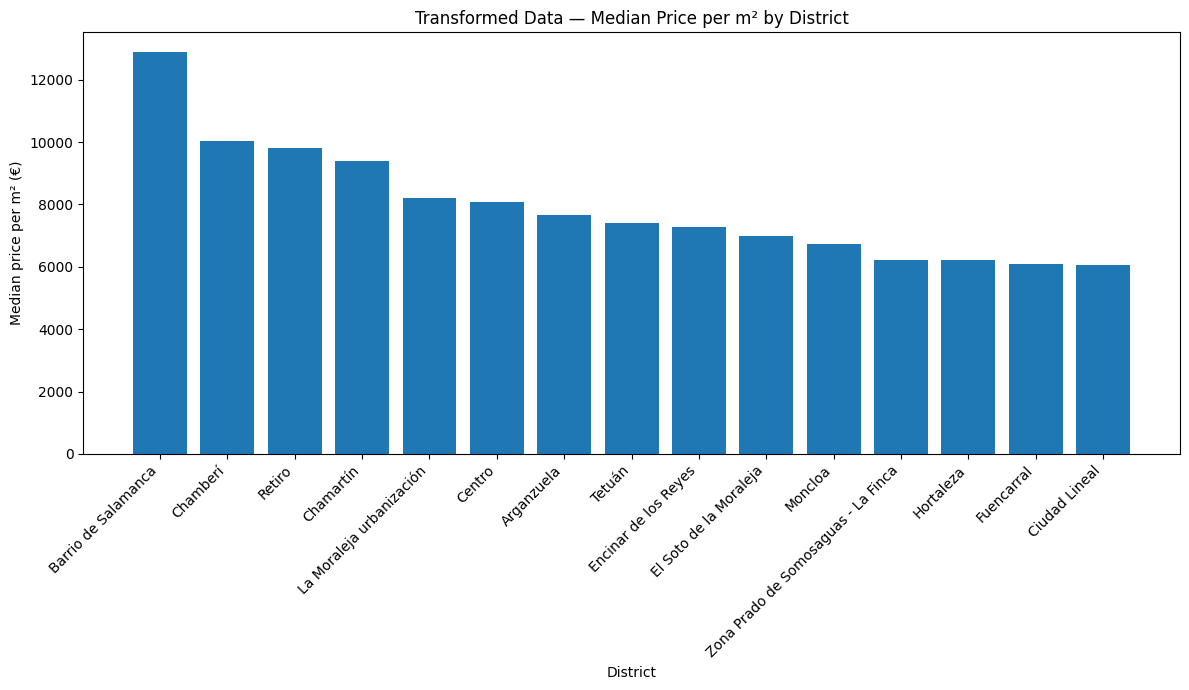

Saved: ..\reports\figures\d4_transformed_price_per_m2_by_district_20260507_175402.png


In [4]:
transformed_df = clean_df.copy() if clean_df is not None else raw_plot_df.copy()

if "price_per_m2" not in transformed_df.columns and {"price", "size"}.issubset(transformed_df.columns):
    transformed_df["price"] = pd.to_numeric(transformed_df["price"], errors="coerce")
    transformed_df["size"] = pd.to_numeric(transformed_df["size"], errors="coerce")
    transformed_df["price_per_m2"] = transformed_df["price"] / transformed_df["size"]

if "district" not in transformed_df.columns:
    raise ValueError("district column not found.")

district_summary = (
    transformed_df
    .dropna(subset=["district", "price_per_m2"])
    .groupby("district")
    .agg(listings=("price_per_m2", "count"), median_price_per_m2=("price_per_m2", "median"))
    .query("listings >= 5")
    .sort_values("median_price_per_m2", ascending=False)
    .head(15)
)

display(district_summary)

plt.figure(figsize=(12, 7))
plt.bar(district_summary.index.astype(str), district_summary["median_price_per_m2"])
plt.title("Transformed Data — Median Price per m² by District")
plt.xlabel("District")
plt.ylabel("Median price per m² (€)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

transformed_fig_path = FIGURES_DIR / f"d4_transformed_price_per_m2_by_district_{timestamp}.png"
plt.savefig(transformed_fig_path, dpi=150)
plt.show()
print("Saved:", transformed_fig_path)


## 5. Visualization 3 — Model performance: test MAE comparison

Objective: compare the three models and justify best model selection.  
Chart type: bar chart.


,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,test_mae,test_rmse,test_r2
0,Gradient Boosting Regressor,"384,269.71","14,423.46","629,174.18","68,638.78",0.79,0.02,"462,609.49","690,149.48",0.82
1,Random Forest Regressor,"428,286.26","18,056.96","692,838.55","90,626.75",0.75,0.03,"498,647.59","785,570.19",0.77
2,Ridge Regression,"471,111.91","26,423.95","672,660.33","56,268.29",0.76,0.02,"525,458.88","841,349.53",0.73


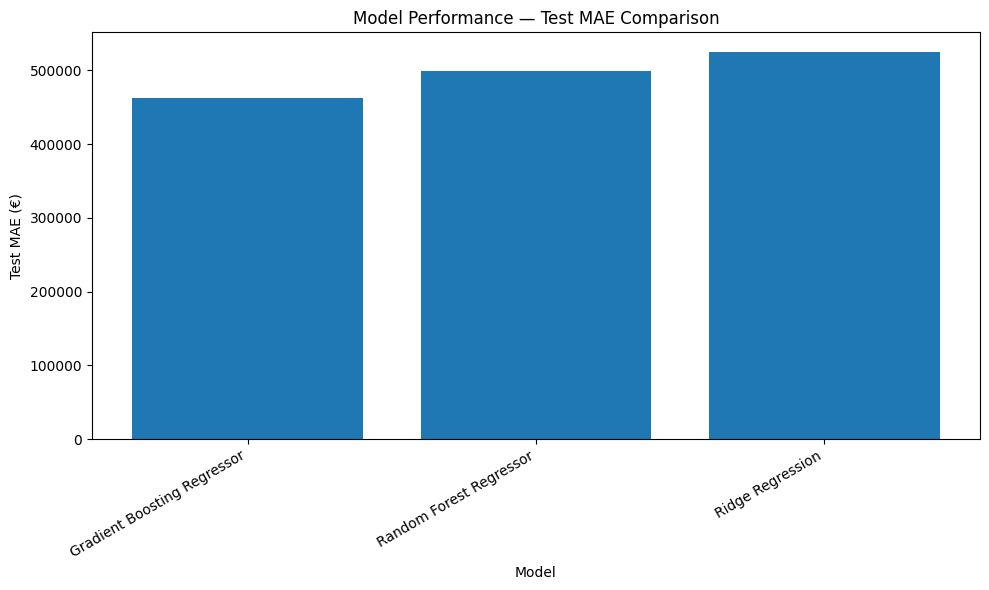

Saved: ..\reports\figures\d4_model_performance_test_mae_20260507_175402.png


In [5]:
if metrics_df is None:
    raise FileNotFoundError("reports/model_metrics_latest.csv not found. Run 04_model_training.ipynb first.")

metrics_plot = metrics_df.copy().sort_values("test_mae")
display(metrics_plot)

plt.figure(figsize=(10, 6))
plt.bar(metrics_plot["model"], metrics_plot["test_mae"])
plt.title("Model Performance — Test MAE Comparison")
plt.xlabel("Model")
plt.ylabel("Test MAE (€)")
plt.xticks(rotation=30, ha="right")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()

model_perf_fig_path = FIGURES_DIR / f"d4_model_performance_test_mae_{timestamp}.png"
plt.savefig(model_perf_fig_path, dpi=150)
plt.show()
print("Saved:", model_perf_fig_path)


## 6. Bonus visualization — Actual vs predicted prices


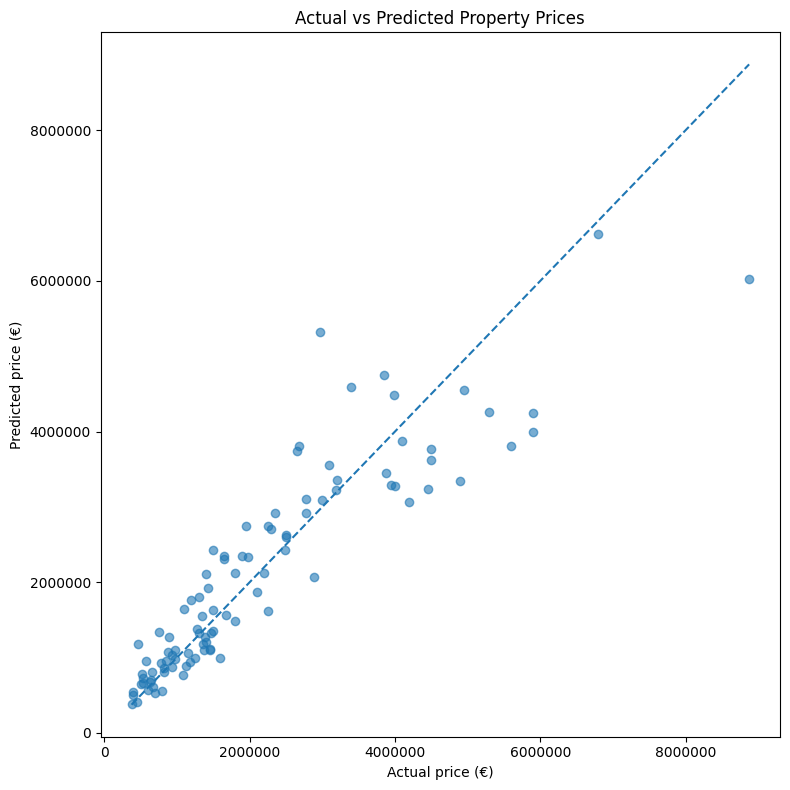

Saved: ..\reports\figures\d4_actual_vs_predicted_20260507_175402.png


In [6]:
if predictions_df is not None and {"actual_price", "predicted_price"}.issubset(predictions_df.columns):
    plt.figure(figsize=(8, 8))
    plt.scatter(predictions_df["actual_price"], predictions_df["predicted_price"], alpha=0.6)
    min_price = min(predictions_df["actual_price"].min(), predictions_df["predicted_price"].min())
    max_price = max(predictions_df["actual_price"].max(), predictions_df["predicted_price"].max())
    plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")
    plt.title("Actual vs Predicted Property Prices")
    plt.xlabel("Actual price (€)")
    plt.ylabel("Predicted price (€)")
    plt.ticklabel_format(style="plain", axis="both")
    plt.tight_layout()
    actual_pred_fig_path = FIGURES_DIR / f"d4_actual_vs_predicted_{timestamp}.png"
    plt.savefig(actual_pred_fig_path, dpi=150)
    plt.show()
    print("Saved:", actual_pred_fig_path)
else:
    print("Predictions file not found or missing required columns.")


## 7. Summary for Assignment 4


In [7]:
print("=== ASSIGNMENT 4 REPORT — VISUALIZATIONS ===")
print("\n1. Raw data visualization")
print("Figure:", raw_price_fig_path)
print("Objective: Show distribution of raw listing prices and identify skewness/outliers.")
print("Chart type: Histogram.")
print("\n2. Transformed data visualization")
print("Figure:", transformed_fig_path)
print("Objective: Show median price per m² by district after feature engineering.")
print("Chart type: Bar chart.")
print("\n3. Model performance visualization")
print("Figure:", model_perf_fig_path)
print("Objective: Compare test MAE across the three trained models.")
print("Chart type: Bar chart.")
if predictions_df is not None:
    print("\nBonus: Actual vs predicted price scatter plot created.")


=== ASSIGNMENT 4 REPORT — VISUALIZATIONS ===

1. Raw data visualization
Figure: ..\reports\figures\d4_raw_price_distribution_20260507_175402.png
Objective: Show distribution of raw listing prices and identify skewness/outliers.
Chart type: Histogram.

2. Transformed data visualization
Figure: ..\reports\figures\d4_transformed_price_per_m2_by_district_20260507_175402.png
Objective: Show median price per m² by district after feature engineering.
Chart type: Bar chart.

3. Model performance visualization
Figure: ..\reports\figures\d4_model_performance_test_mae_20260507_175402.png
Objective: Compare test MAE across the three trained models.
Chart type: Bar chart.

Bonus: Actual vs predicted price scatter plot created.
